# Traffic Demand Prediction - Test Profile

This notebook profiles `test.csv`, compares it against train, and checks schema/category drift before modeling.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dataset').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'dataset'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_PATH = DATA_DIR / 'sample_submission.csv'

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/underxcore/Desktop/Flipkart_GridLock


In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
print('train:', train.shape)
print('test:', test.shape)
display(test.head())

train: (77299, 11)
test: (41778, 10)


,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.4762,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.3182,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.2662,Foggy


## Schema Checks

In [3]:
expected_test_cols = [c for c in train.columns if c != 'demand']
print('Expected test columns match:', list(test.columns) == expected_test_cols)
display(pd.DataFrame({'train_columns': train.columns.tolist(), 'test_columns': test.columns.tolist() + ['<no target>']}))

Expected test columns match: True


,train_columns,test_columns
0,Index,Index
1,geohash,geohash
2,day,day
3,timestamp,timestamp
4,demand,RoadType
5,RoadType,NumberofLanes
6,NumberofLanes,LargeVehicles
7,LargeVehicles,Landmarks
8,Landmarks,Temperature
9,Temperature,Weather


## Missing Values

In [4]:
missing_compare = pd.DataFrame({
    'train_missing_pct': train.drop(columns=['demand']).isna().mean() * 100,
    'test_missing_pct': test.isna().mean() * 100,
}).round(2)
missing_compare

,train_missing_pct,test_missing_pct
Index,0.0000,0.0000
geohash,0.0000,0.0000
day,0.0000,0.0000
timestamp,0.0000,0.0000
RoadType,0.7800,0.7800
NumberofLanes,0.0000,0.0000
LargeVehicles,0.0000,0.0000
Landmarks,0.0000,0.0000
Temperature,3.2300,3.2300
Weather,1.0300,1.0300


## Temporal Coverage

In [5]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    hm = out['timestamp'].astype(str).str.split(':', expand=True).astype(int)
    out['hour'] = hm[0]
    out['minute'] = hm[1]
    out['minute_of_day'] = out['hour'] * 60 + out['minute']
    out['global_minute'] = out['day'] * 24 * 60 + out['minute_of_day']
    out['time_sin'] = np.sin(2 * np.pi * out['minute_of_day'] / (24 * 60))
    out['time_cos'] = np.cos(2 * np.pi * out['minute_of_day'] / (24 * 60))
    out['is_morning_peak'] = out['hour'].between(7, 10).astype(int)
    out['is_evening_peak'] = out['hour'].between(16, 20).astype(int)
    out['is_night'] = ((out['hour'] <= 5) | (out['hour'] >= 22)).astype(int)
    return out

train_t = add_time_features(train)
test_t = add_time_features(test)
display(train_t.groupby('day')['minute_of_day'].agg(['min', 'max', 'count']))
display(test_t.groupby('day')['minute_of_day'].agg(['min', 'max', 'count']))

,min,max,count
day,,,
48,0,1425,69427
49,0,120,7872


,min,max,count
day,,,
49,135,825,41778


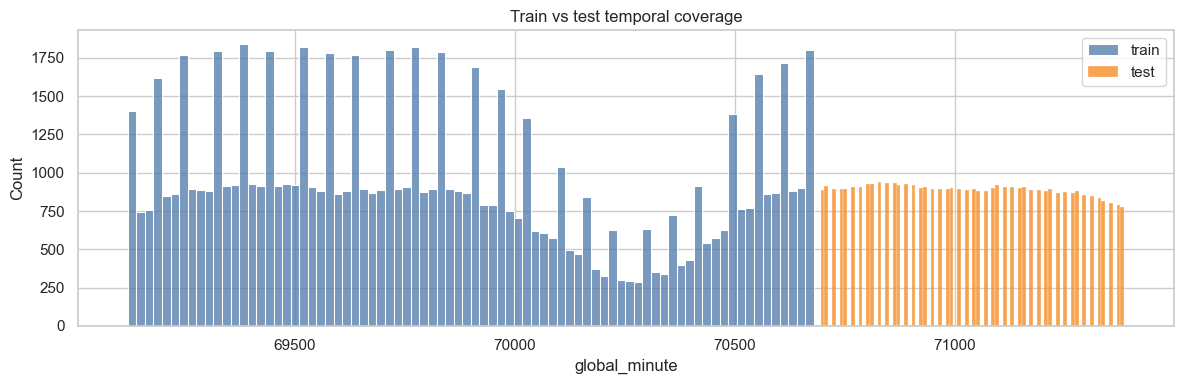

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(train_t['global_minute'], bins=80, color='#4c78a8', label='train', ax=ax)
sns.histplot(test_t['global_minute'], bins=80, color='#f58518', label='test', ax=ax)
ax.set_title('Train vs test temporal coverage')
ax.legend()
plt.tight_layout()

## Category and Geohash Drift

In [7]:
for col in ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'NumberofLanes']:
    train_values = set(train[col].dropna().astype(str))
    test_values = set(test[col].dropna().astype(str))
    print(f'{col}: unseen in test = {sorted(test_values - train_values)}')

train_geo = set(train['geohash'])
test_geo = set(test['geohash'])
print(f'Train geohashes: {len(train_geo):,}')
print(f'Test geohashes: {len(test_geo):,}')
print(f'Test geohashes not in train: {len(test_geo - train_geo):,}')
print(f'Test rows with known train geohash: {test.geohash.isin(train_geo).mean():.2%}')

RoadType: unseen in test = []
LargeVehicles: unseen in test = []
Landmarks: unseen in test = []
Weather: unseen in test = []
NumberofLanes: unseen in test = []
Train geohashes: 1,249
Test geohashes: 1,190
Test geohashes not in train: 10
Test rows with known train geohash: 99.94%


In [8]:
coverage = pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [len(train), len(test)],
    'unique_geohash': [train.geohash.nunique(), test.geohash.nunique()],
    'unique_timestamp': [train.timestamp.nunique(), test.timestamp.nunique()],
    'min_day': [train.day.min(), test.day.min()],
    'max_day': [train.day.max(), test.day.max()],
})
coverage

,dataset,rows,unique_geohash,unique_timestamp,min_day,max_day
0,train,77299,1249,96,48,49
1,test,41778,1190,47,49,49


## Test Profile Notes

- Test has the same feature columns as train after removing the target.
- Missing-value rates are nearly identical, which supports a shared preprocessing pipeline.
- Any unseen categories are handled safely by `OneHotEncoder(handle_unknown="ignore")` in the modeling notebook.